In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt 
import torch.nn.functional as F
%matplotlib inline

In [13]:
with open('../data/names.txt', 'r') as f:
    names = f.read().splitlines()
print(names[:10])

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']


In [14]:
charset = ['.'] + sorted(list(set(''.join(names))))
stoi = {s:i for i,s in enumerate(charset)}
itos = {i:s for i,s in stoi.items()}

vocab_size = len(charset)

In [15]:
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            Y.append(ix)
            X.append(context)
            context = context[1:] + [ix]
    XS, YS = torch.tensor(X), torch.tensor(Y)
    print(XS.shape, YS.shape)
    return XS, YS

training_p = .8
dev_p = 0.1
test_p = 0.1

data_size = len(names)

tr_split = int(data_size * training_p)
dev_split = int((training_p + dev_p) * data_size)

import random
random.shuffle(names)
Xtr, ytr = build_dataset(names[:tr_split])
Xdev, ydev = build_dataset(names[tr_split: dev_split])
Xtest, ytest = build_dataset(names[dev_split:])

torch.Size([182494, 3]) torch.Size([182494])
torch.Size([22944, 3]) torch.Size([22944])
torch.Size([22708, 3]) torch.Size([22708])


In [16]:
embed_dim = 10
hidden_neurons = 200
batch_size = 32

rng = torch.Generator().manual_seed(13)
C = torch.randn(size=(vocab_size, embed_dim), generator=rng)
W1 = torch.randn(size=(embed_dim*block_size, hidden_neurons), generator=rng)
b1 = torch.randn(size=(hidden_neurons, ), generator=rng)
W2 = torch.randn(size=(hidden_neurons, vocab_size), generator=rng)
b2 = torch.randn(size=(vocab_size, ), generator=rng)

parameters = [C, W1, b1, W2, b2]
print(f'total parameters : { sum( p.nelement() for p in parameters)}')

for p in parameters:
    p.requires_grad = True

total parameters : 11897


In [17]:
#trg loop
epochs = 200000
learning_rate = 0.1
lossi = []
for epoch in range(epochs):
    batch = torch.randint(0, len(Xtr), size=(batch_size, ), generator=rng)
    Xb, yb = Xtr[batch], ytr[batch]

    emb = C[Xb]
    embcat = emb.view(-1, embed_dim*block_size)
    h = embcat @ W1 + b1
    hactive = torch.tanh(h)

    logits = hactive @ W2 + b2
    counts = logits.exp()
    ypred = counts / counts.sum(1, keepdim=True)

    loss = -ypred[torch.arange(batch_size), yb].log().mean()

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = learning_rate if epoch < epochs / 2 else learning_rate / 10
    for p in parameters:
        p.data = p.data -lr * p.grad

    if epoch % 10000 == 0:
        print(f'epoch: {epoch} | {epochs} : {loss.item(): .4f}')
    lossi.append(loss.log10().item())

epoch: 0 | 200000 :  27.6342
epoch: 10000 | 200000 :  2.4515
epoch: 20000 | 200000 :  2.4818
epoch: 30000 | 200000 :  2.3566
epoch: 40000 | 200000 :  2.5223
epoch: 50000 | 200000 :  2.5971
epoch: 60000 | 200000 :  2.1420
epoch: 70000 | 200000 :  2.2601
epoch: 80000 | 200000 :  2.0108
epoch: 90000 | 200000 :  2.4286
epoch: 100000 | 200000 :  2.0335
epoch: 110000 | 200000 :  2.3318
epoch: 120000 | 200000 :  2.1421
epoch: 130000 | 200000 :  1.7887
epoch: 140000 | 200000 :  2.2618
epoch: 150000 | 200000 :  2.0046
epoch: 160000 | 200000 :  2.0128
epoch: 170000 | 200000 :  2.2317
epoch: 180000 | 200000 :  2.0657
epoch: 190000 | 200000 :  2.0506


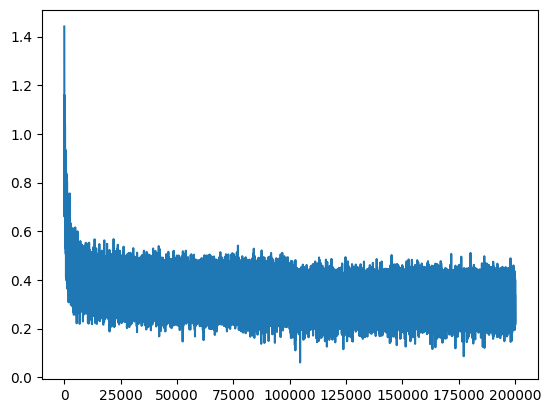

In [18]:
plt.plot(lossi)